In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
# Constants
parent_folder  = "results"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = True

Found 12 results


In [3]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))

# https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4

# plt.rcParams.keys()

In [4]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    # Local Processing
    if float(_params[4]) == 3.0: # and float(_params[5]) <=3 and float(_params[3]) == 0.5:
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


100%|██████████| 12/12 [00:00<00:00, 40.29it/s]

We ended up with 120000 rows


In [5]:
# Calculate Precision and Recall
print("Calculate precision and recall")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")


Calculate precision and recall
Recall done
Precision done


In [15]:
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df['Consensus Accuracy'] = df.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

df_def = df.drop(df[df.Algorithm != 2].index)
df_good = df.drop(df[df['Consensus Accuracy'] == 1].index)


Consensus Accuracy done


In [19]:
# Reduce dataset for tests XXX
# df_def = df.drop(df[df.repetition > 0].index)
# df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)
df_def

,Epoch,sources,malign,ban_sources,ban_malign,consensus,rep_benign,rep_malign,rep_min,ratio_malign,alpha,tolerance,repetition,Algorithm,Recall,Precision,Consensus Accuracy
10000,0,500,0,0,0,24.316857,0.008905,0.000000,-0.6,0.75,0.5,3.0,0.0,2.0,0.0,0,1
10001,1,500,0,0,0,24.111556,0.017763,0.000000,-0.6,0.75,0.5,3.0,0.0,2.0,0.0,0,1
10002,2,500,0,0,0,23.586135,0.025873,0.000000,-0.6,0.75,0.5,3.0,0.0,2.0,0.0,0,1
10003,3,501,0,0,0,26.903335,0.032429,0.000000,-0.6,0.75,0.5,3.0,0.0,2.0,0.0,0,1
10004,4,501,0,0,0,25.224142,0.041321,0.000000,-0.6,0.75,0.5,3.0,0.0,2.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109995,9995,1000,500,0,0,28.484070,0.626016,-0.037721,-0.6,1.00,0.5,3.0,0.0,2.0,0.0,0,0
109996,9996,1000,500,0,0,23.220522,0.625779,-0.036249,-0.6,1.00,0.5,3.0,0.0,2.0,0.0,0,1
109997,9997,1000,500,0,0,21.804730,0.626602,-0.033943,-0.6,1.00,0.5,3.0,0.0,2.0,0.0,0,0
109998,9998,1000,500,0,0,24.126911,0.627776,-0.033368,-0.6,1.00,0.5,3.0,0.0,2.0,0.0,0,1


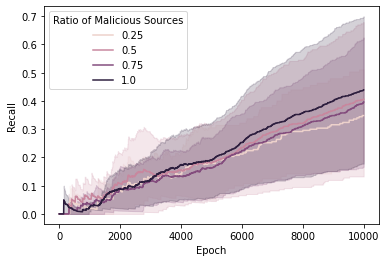

In [14]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

Doing min_rep_over_time.png
min_rep_over_time.pngDone


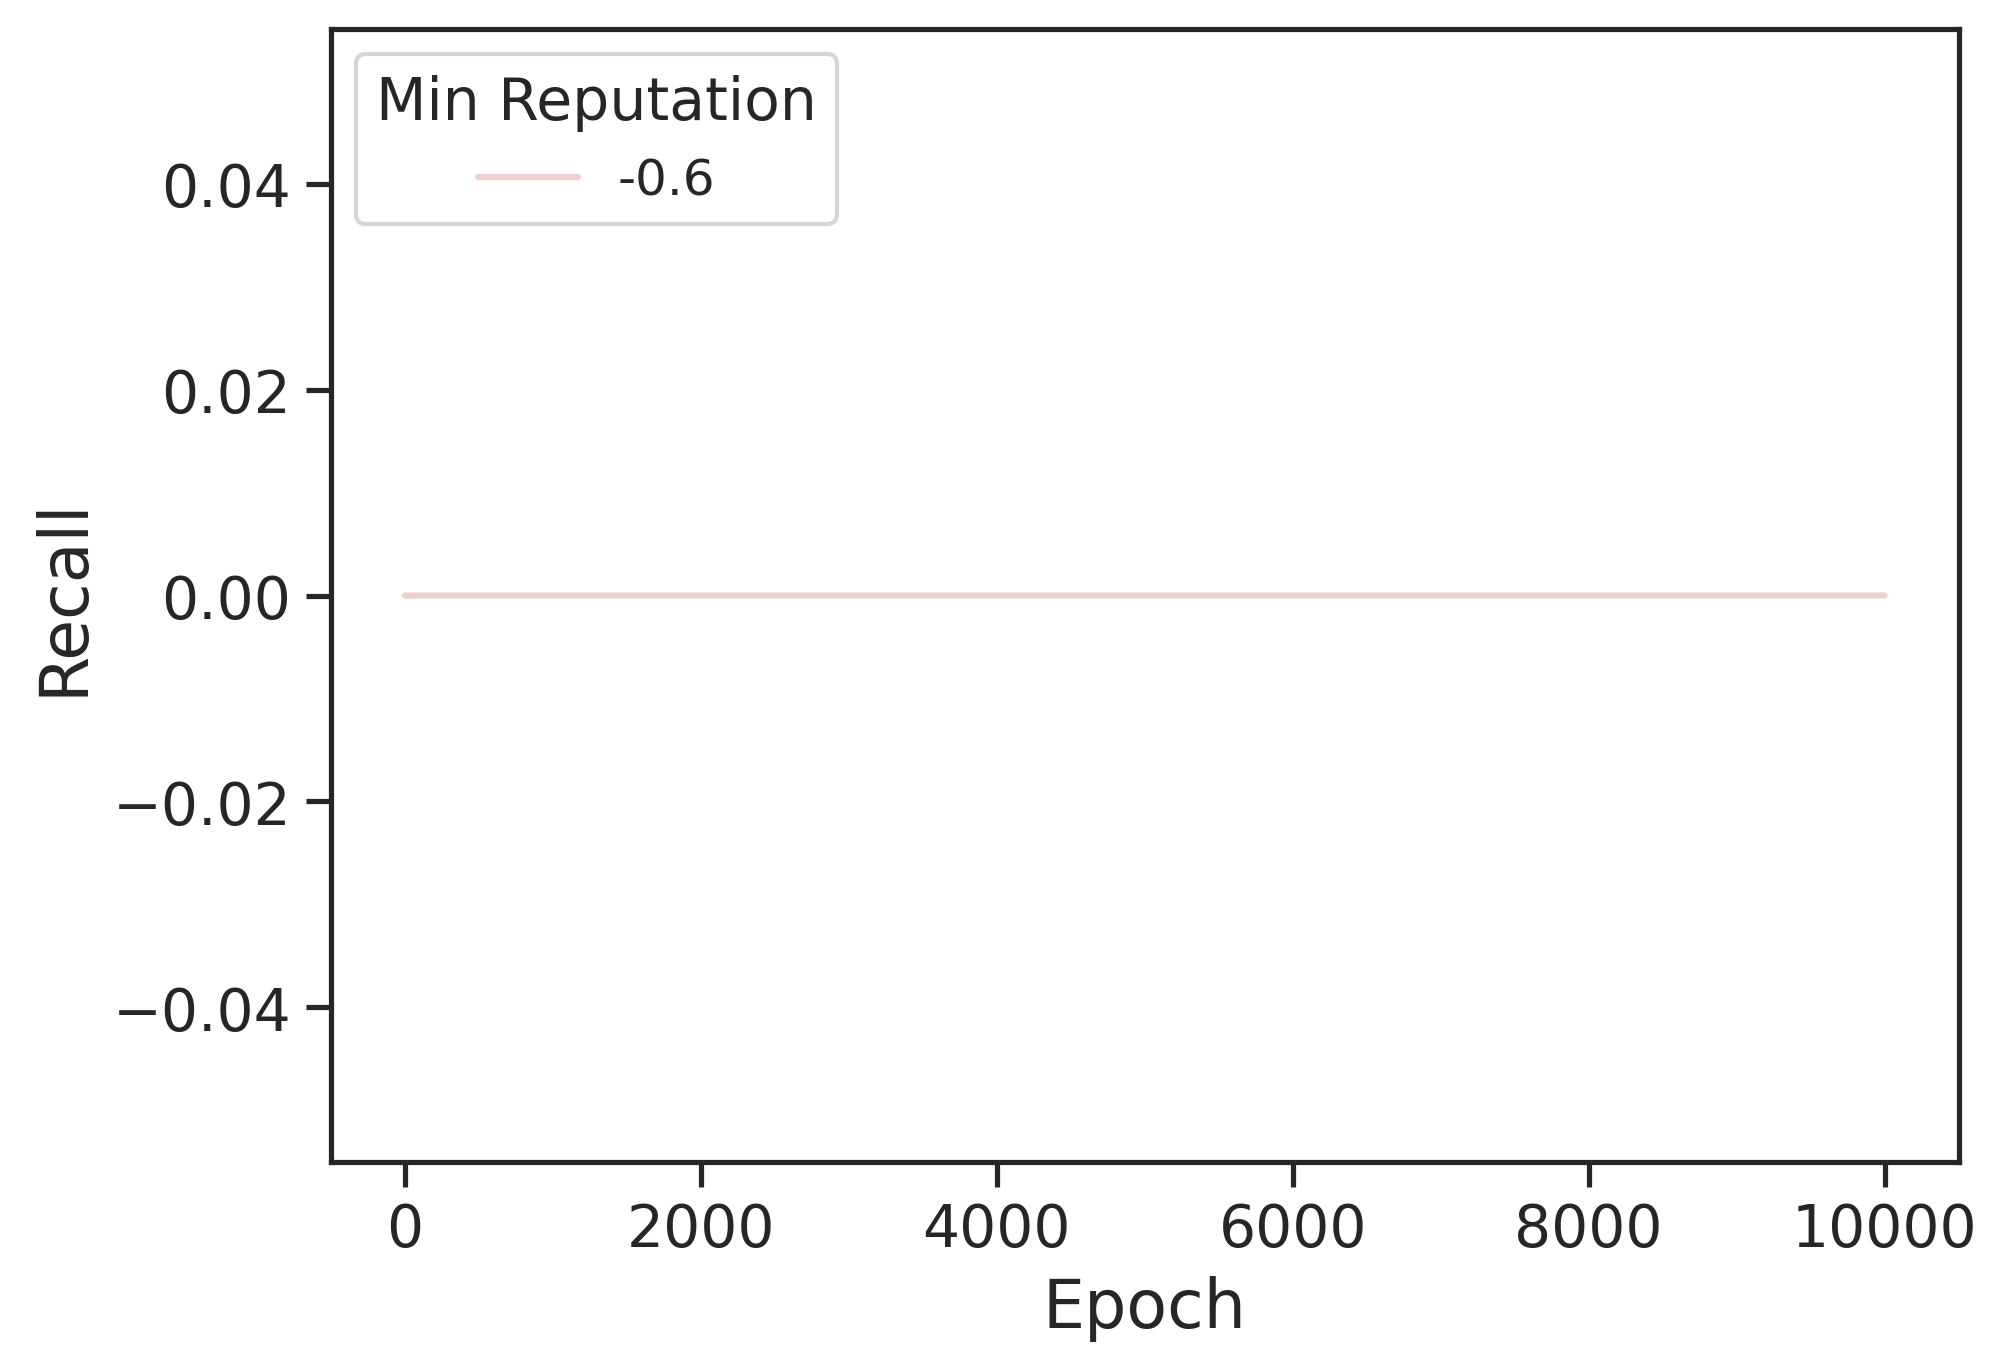

In [18]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min')
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [7]:
# PLOT 1 [DISCARD PLOT] - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min')
        plt.legend(title='Min Reputation', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

IndentationError: unexpected indent (731449446.py, line 5)

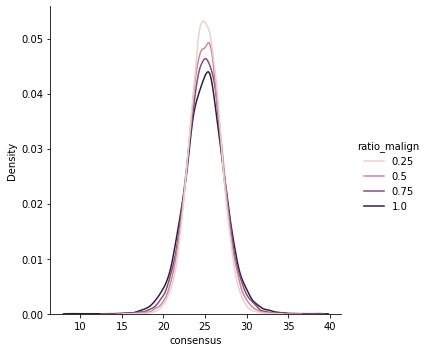

In [11]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

No handles with labels found to put in legend.


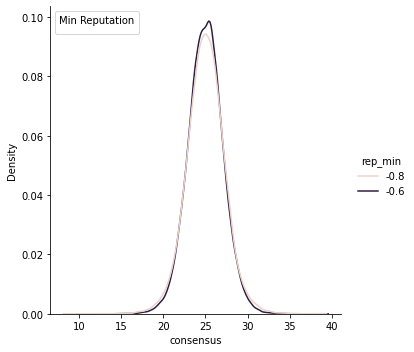

In [21]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

Doing algorithm_comparison.png
1016.0
1387.0
1702.0
2219.0
1152.0
1410.0
1787.0
2191.0
1064.0
1546.0
1883.0
2292.0
algorithm_comparison.png Done!


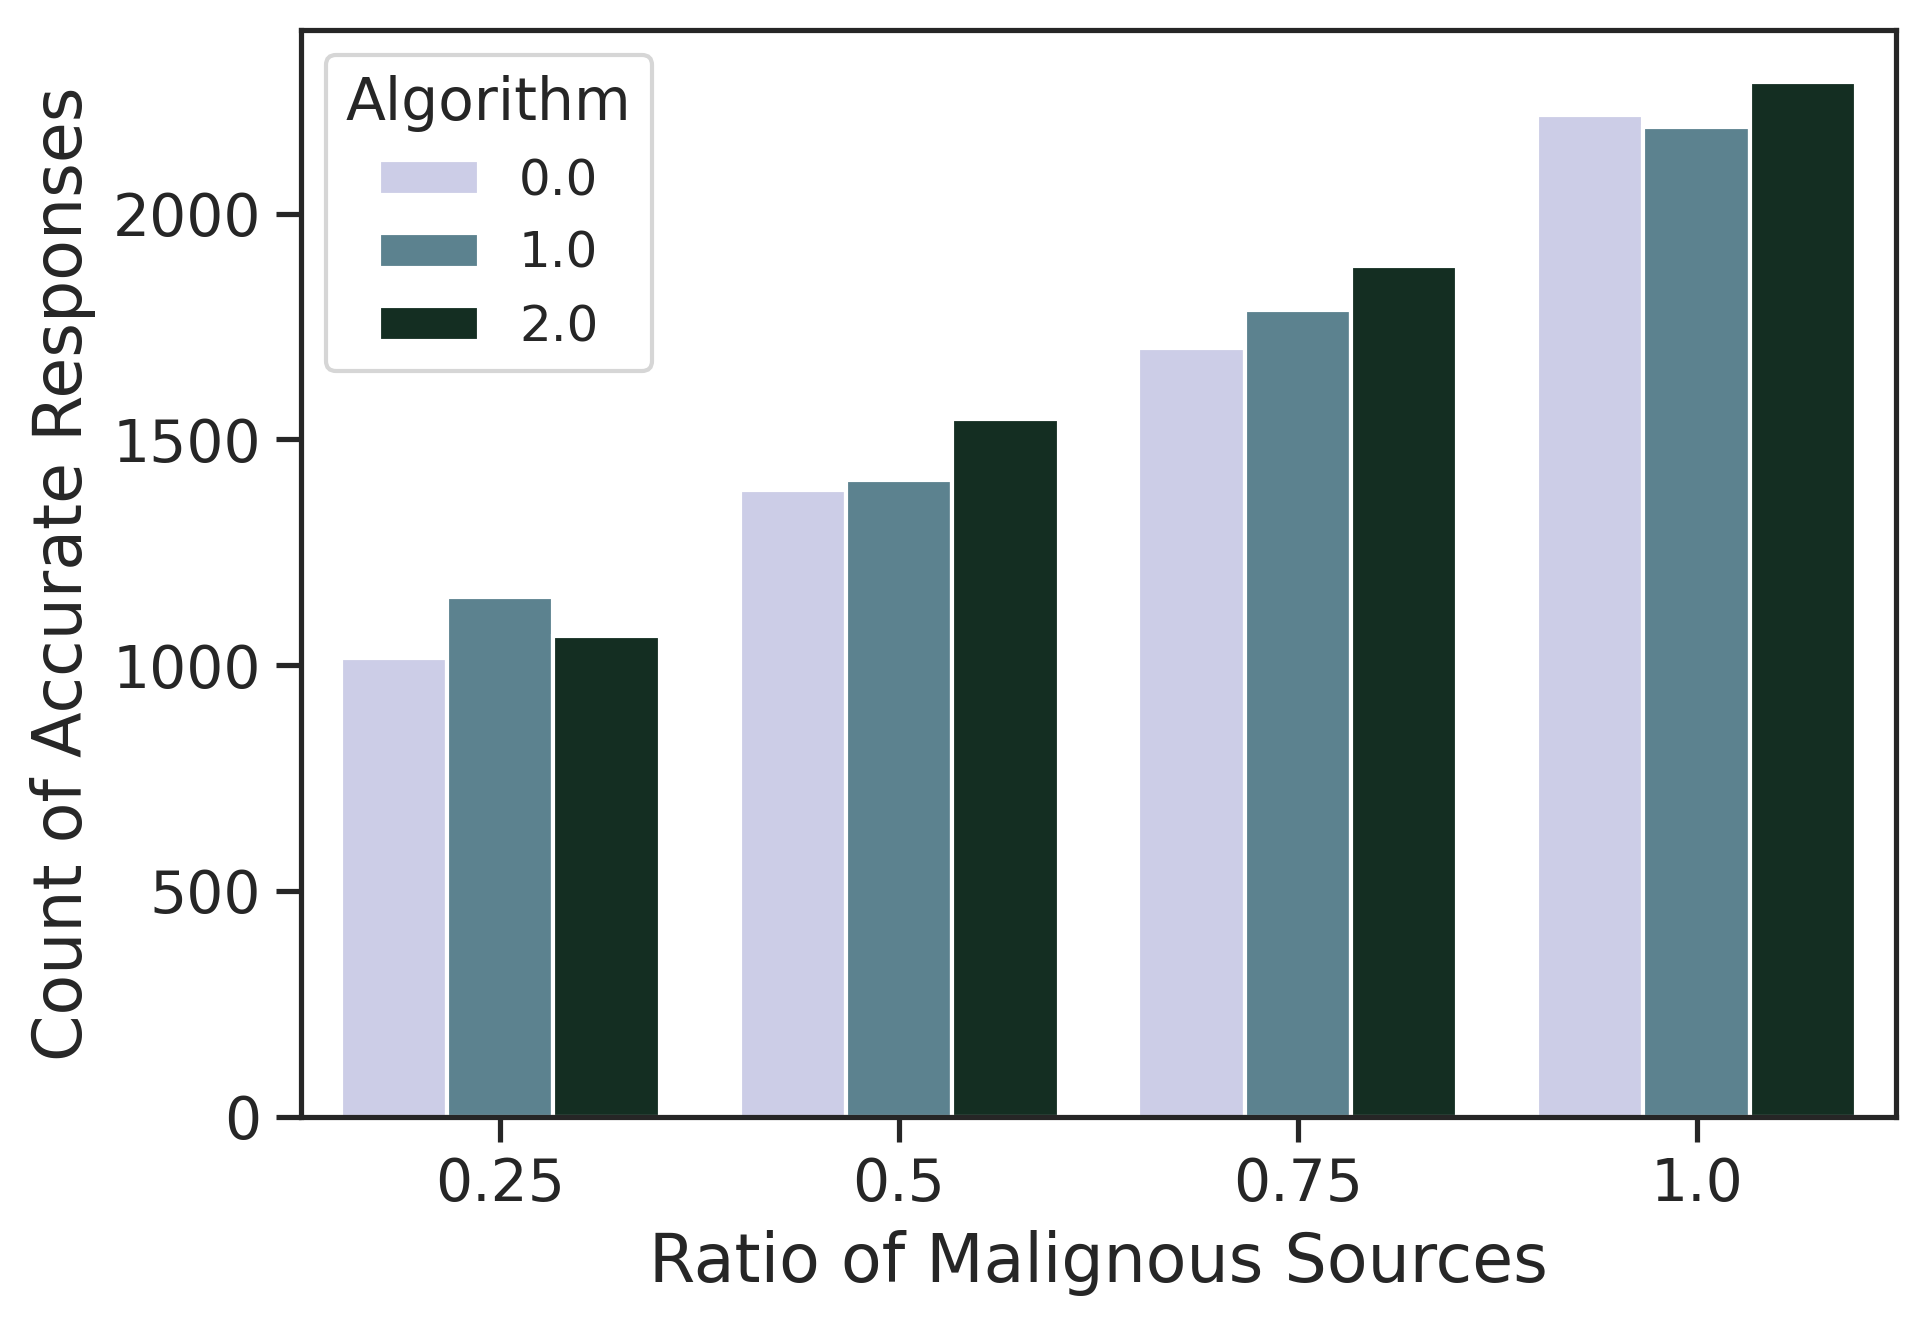

In [17]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

img_name = "algorithm_comparison.png"
if _REPLACE_ or not os.path.exists(img_name):
    print("Doing " + img_name)
    ax = sns.countplot(data=df_good, x='ratio_malign', hue='Algorithm')
    for p in ax.patches:
        print( p.get_height() )
    plt.legend(title='Algorithm', loc='upper left')
    ax.set_xlabel('Ratio of Malignous Sources', fontsize=16)
    ax.set_ylabel('Count of Accurate Responses', fontsize=16)

    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


KeyboardInterrupt: 

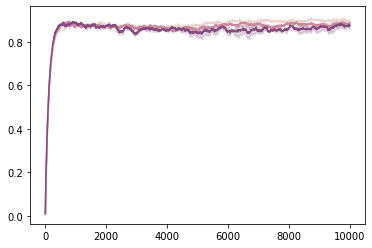

In [22]:
# df_use = df_def
# df_good = df_use.drop(df[df.repetition > 0].index)


# # PLOT 1
# sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign')
# sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign')
# plt.legend(title='Ratio malicious', loc='upper left')
# #plt.savefig("min_rep_over_time.png", dpi=300)
# plt.show()